<a href="https://colab.research.google.com/github/guadalupesbel-commits/EstadisticaVerano2026/blob/main/Studentperformance/Student_Performance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/guadalupesbel-commits/EstadisticaVerano2026/refs/heads/main/Studentperformance/Student_Performance.csv")

df

,Hours_Studied,Previous_Scores,Extracurricular_Activities,Sleep_Hours,Sample_Question_Papers_Practiced,Performance_Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


Establecemos las horas de estudio (Hours_Studied) como variable dependiente y el indice de desempeño ("Performance_Index") como la variable independiente. Esto es porque la hipotesis inicial es que cambios en las horas de estudio puede cambiar en el ínidice de desempeño, sin embargo cambios en los índices de desempeño no causa cambios en las horas d estudio.

In [9]:
X = df ["Hours_Studied"]      #Variable independiente
Y = df ["Performance_Index"]  #Variable dependiente

2. **Realice un diagrama de dispersión**

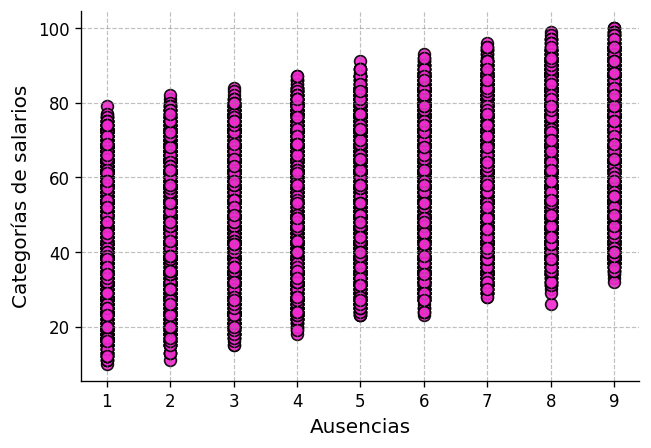

In [10]:
# Importamos la librería matplotlib.pyplot y le damos el pseudónimo plt
import matplotlib.pyplot as plt

# Configuración general del gráfico
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# Gráfico de dispersión
plt.scatter(
    X, Y,
    marker="o",       # forma: googlear "matplotlib.markers"
    color='#F527D3',     # color de los puntos
    edgecolor='black',    # borde de los puntos
    alpha=0.9,            # transparencia: 0 es invisible y 1 es color sólido
    s=50,                 # tamaño de los puntos
)

# Etiquetas de los ejes
# eje x
plt.xlabel(
    'Ausencias', # etiqueta del eje x
    fontsize=12  # tamaño de fuente
)

plt.ylabel(
    'Categorías de salarios', # etiqueta del eje y
    fontsize=12 # tamaño de fuente
)

# Fuente de los ticks
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Márgenes
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Cuadrícula (opcional, pero didáctica)
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.5,
    color="gray"
)

El gráfico de disperción muestra una clara tendencia lineal. Se puede observar que conforme aumentan las horas de estudio ($X$) aumenta el índice de desempeño ($Y$). Con lo que se espera un coefieciente de corelación positivo y parece cumplirse el supuesto de linealidad.

In [11]:
# Importar la función pearsonr desde scipy.stats
from scipy.stats import pearsonr

# Test de Pearson
# H0: rho = 0     (No hay correlación)
# H1: rho ≠ 0     (Sí hay correlación)
# alpha = 0.05

r, valor_p = pearsonr(X, Y)

print(f"Coeficiente de correlaciòn: {r: 0.4f}")
print(f'valor_p: {valor_p: 0.4f}')

Coeficiente de correlaciòn:  0.3737
valor_p:  0.0000


El coeficiente de correlación es $r=0.3737$

In [12]:
import statsmodels.api as sm
x_constante = sm.add_constant(X)
modelo = sm.OLS(Y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

In [13]:
# Coeficiente de determinación
from sklearn.metrics import r2_score

r2 = r2_score(Y, y_calculada)

print(f"Coeficiente de determinación: {r2: 0.2%}")

Coeficiente de determinación:  13.97%


Una vez ajustado el modelo de regresión lineal, se obtiene un coeficiente de determinación de $Rˆ2=0.1397$.
Entonces teniendo las horas de estudio y el modelo ajustado, sólo podemos justificar la variabilidad en las calificaciones en un 13.97%, lo que es muy bajo para poder realizar predicciones precisas.

In [15]:
modelo.conf_int(alpha=0.05)

,0,1
const,40.620341,42.138008
Hours_Studied,2.638143,2.907983


La interción tiene un nivel de confianza del 95% de $[40.62,42.14]$. Esto significa que se tiene un nivel de confianza del 95%